____
# TEST SWOT ON SYNTHETIC GRAD

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


_______
# Data

In [2]:
dfs = browse_swot_250().reset_index()
drifters_sources = "all_med_variational_10min_v0.nc"
df = pd.read_csv(
    os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv"))
)  # .drop(columns='Unnamed: 0')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_20345/1524825581.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))#.drop(columns='Unnamed: 0')


In [4]:
df.columns

Index(['row_number', 'pass_number', 'drifter_id', 'datetime', 'x', 'y',
       'drifter_type', 'cruise_id', 'lonc', 'latc', 'longitude', 'latitude',
       'velocity_east', 'velocity_north', 'velocity', 'acceleration_east',
       'acceleration_north', 'acceleration', 'X', 'gap_mask', 'gaps',
       'inside_left', 'inside_right', 'time_to_swot', 'cycle_number'],
      dtype='object')

__________
# SWOT

In [3]:
# get grid orientation and metrics
def add_grid_metrics(ds):
    """add grid spatial metrics"""

    geod = Geod(ellps="WGS84")

    lon, lat = ds.longitude, ds.latitude
    dims = lon.dims

    # d/dx where x is cross-track
    az12, az21, dx = geod.inv(
        lon,
        lat,
        lon.shift(num_pixels=-1),
        lat.shift(num_pixels=-1),
    )

    ds = ds.assign_coords(dx=(dims, dx), phi=(dims, az12 * np.pi / 180))

    ds["dx"] = ds["dx"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # phi_lon is cross-track direction from north
    ds["phix"] = ds["phi"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    # d/dy where y is along-track
    az12, az21, dy = geod.inv(
        lon,
        lat,
        lon.shift(num_lines=-1),
        lat.shift(num_lines=-1),
    )

    # phiy is along-track direction from north
    ds = ds.assign_coords(phi=(dims, az12 * np.pi / 180))
    ds["phiy"] = ds["phi"].ffill("num_pixels").where(ds["duacs_editing_flag"] < 5)

    ds = ds.assign_coords(dy=(dims, dy))

    ds["dy"] = ds["dy"].ffill("num_lines").where(ds["duacs_editing_flag"] < 5)
    ds["phi"] = ds["phix"]
    return ds

In [4]:
cycle = 500
swath = 3

dss = xr.open_dataset(
    dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
    .dropna()
    .file.values[0]
)
dss = add_grid_metrics(dss)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [5]:
eta = np.zeros_like(dss.duacs_ssha_karin_2_filtered)

for i in range(np.shape(eta)[0]):
    eta[i] = np.arange(0, len(eta[0])) / 100

dss["eta"] = xr.DataArray(eta, dims=["num_lines", "num_pixels"]).where(
    ~dss["duacs_ssha_karin_2_filtered"].isnull()
)

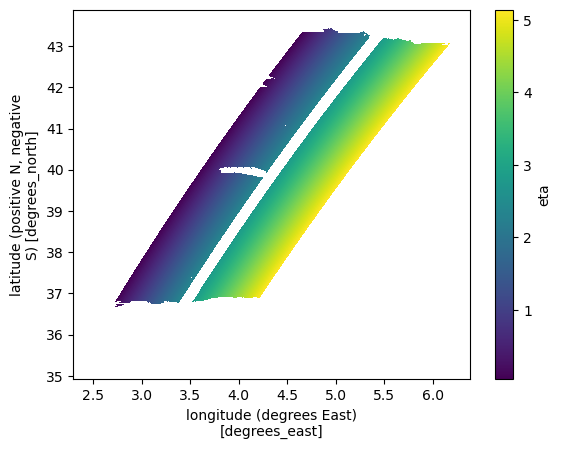

In [6]:
dss.eta.plot(x="longitude", y="latitude")

In [7]:
ggrad_variables = [
    "eta",
    "duacs_ssha_karin_2_filtered",
]

variables = [
    "ancillary_surface_classification_flag",
    "cross_track_distance",
    "cvl_distance_to_coast",
    "cvl_swh_model",
    "duacs_editing_flag",
    "duacs_phase_screen",
    "duacs_phase_screen_orbit",
    "duacs_phase_screen_static",
    "duacs_relative_vorticity",
    "duacs_speed_meridional",
    "duacs_speed_meridional_abs",
    "duacs_speed_zonal",
    "duacs_speed_zonal_abs",
    "duacs_strain",
    "duacs_xcal",
    "sig0_karin_2",
    "ssh_karin_2_qual",
    "phi",
]

# Compute gradient

## Naive way

In [8]:
9.81 * 0.01 / 250

0.00039240000000000005

In [9]:
# Compute ggrad with "naive" approach, noise will have an impact
g = 9.80665


def gradient_naive(dss, ggrad_variables=None):
    if ggrad_variables:
        dss_ggrad = dss[ggrad_variables]
    dx = dss_ggrad.dx.mean()  # meters
    dy = dss_ggrad.dy.mean()

    dss_ggradx = (g * dss_ggrad.differentiate("num_pixels") / dx).rename(
        {v: "ggradx_" + v for v in dss_ggrad}
    )
    dss_ggrady = (g * dss_ggrad.differentiate("num_lines") / dy).rename(
        {v: "ggrady_" + v for v in dss_ggrad}
    )
    return xr.merge([dss_ggradx, dss_ggrady])


dss_naive = gradient_naive(dss, ggrad_variables)
dss_naive

<xarray.Dataset> Size: 155MB
Dimensions:                             (num_lines: 4161, num_pixels: 519)
Coordinates:
    latitude                            (num_lines, num_pixels) float64 17MB ...
    longitude                           (num_lines, num_pixels) float64 17MB ...
    dx                                  (num_lines, num_pixels) float64 17MB ...
    phi                                 (num_lines, num_pixels) float64 17MB ...
    dy                                  (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    ggradx_eta                          (num_lines, num_pixels) float64 17MB ...
    ggradx_duacs_ssha_karin_2_filtered  (num_lines, num_pixels) float64 17MB ...
    ggrady_eta                          (num_lines, num_pixels) float64 17MB ...
    ggrady_duacs_ssha_karin_2_filtered  (num_lines, num_pixels) float64 17MB ...

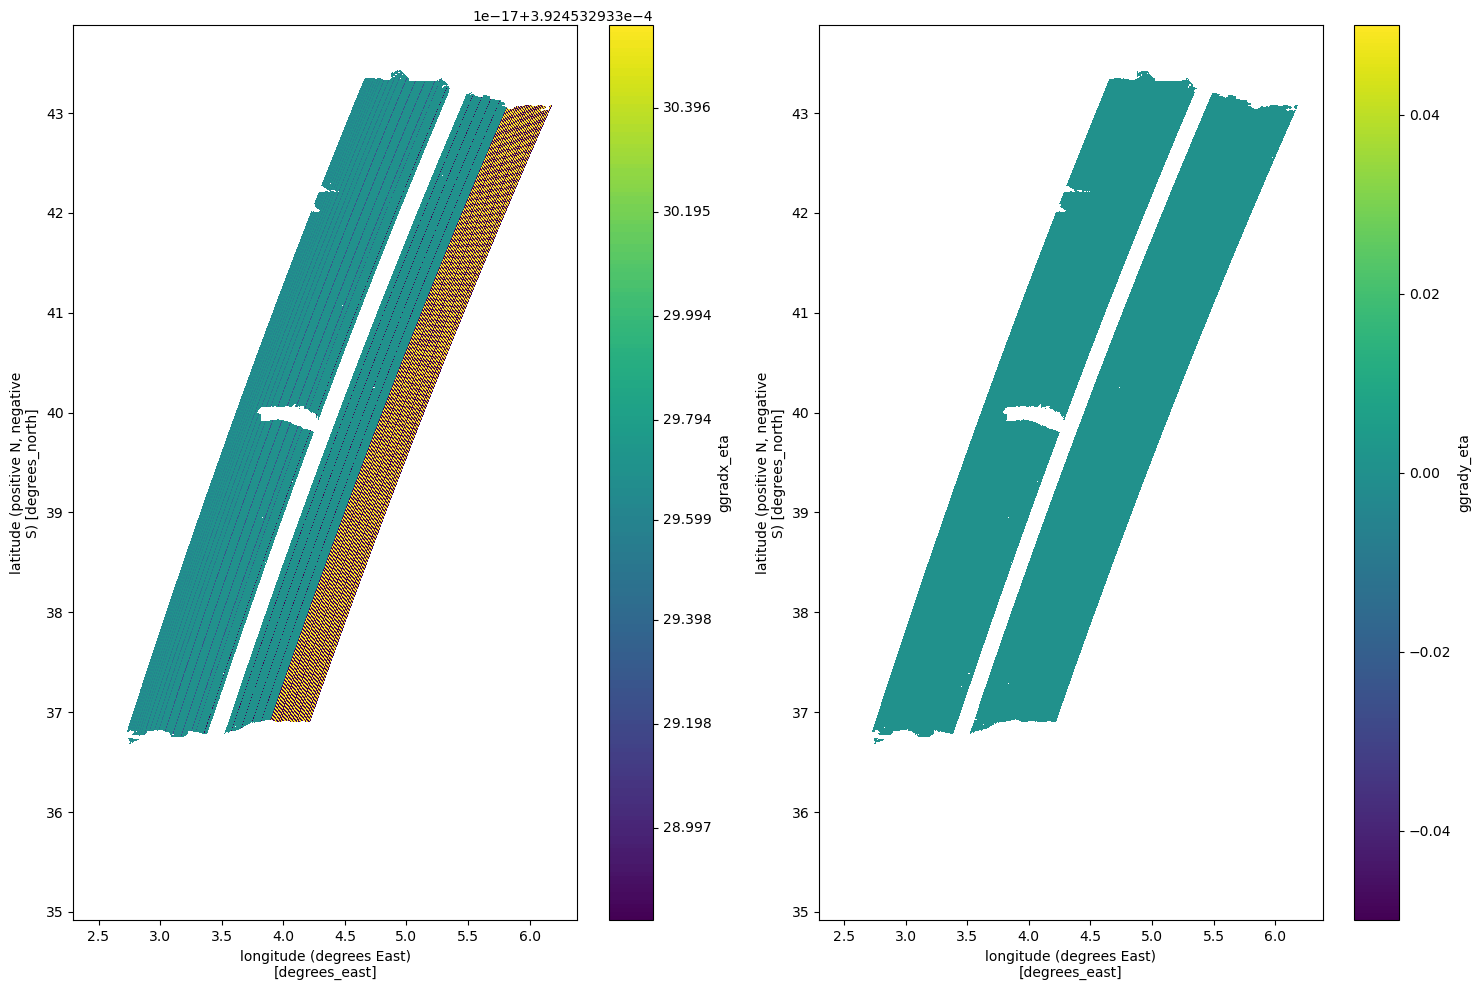

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 10))
dss_naive.ggradx_eta.plot(x="longitude", y="latitude", ax=axs[0])
dss_naive.ggrady_eta.plot(x="longitude", y="latitude", ax=axs[1])
fig.tight_layout()

## Gaussian gradient

In [11]:
# gaussian derivative
from scipy.ndimage import gaussian_filter


def gradient_gauss(dss, ggrad_variables=None, cutoff=1e3, **kwargs):

    if ggrad_variables:
        dss_ggrad = dss[ggrad_variables]

    dx = float(dss_ggrad.dx.mean())
    dy = float(dss_ggrad.dy.mean())

    dss_ggradx = xr.Dataset()
    dss_ggrady = xr.Dataset()

    for v in dss_ggrad:
        da = (
            dss_ggrad[v]
            .interpolate_na(dim="num_pixels")
            .interpolate_na(dim="num_lines")
        )  # prevent nan to spread

        # cross-track
        i = da.get_axis_num("num_pixels")
        order = [0, 0]
        order[i] = 1
        dss_ggradx["ggradx_" + v] = g * (
            xr.DataArray(
                gaussian_filter(da, sigma=cutoff / dx, order=order, **kwargs),
                dims=da.dims,
            )
            / dx
        ).where(~dss[v].isnull())
        # da_dx = da_dx.where(da)

        # along-track
        i = da.get_axis_num("num_lines")
        order = [0, 0]
        order[i] = 1
        dss_ggrady["ggrady_" + v] = g * (
            xr.DataArray(
                gaussian_filter(da, sigma=cutoff / dy, order=order, **kwargs),
                dims=da.dims,
            )
            / dy
        ).where(~dss[v].isnull())

    return xr.merge([dss_ggradx, dss_ggrady])


dss_gauss = gradient_gauss(dss, ggrad_variables)

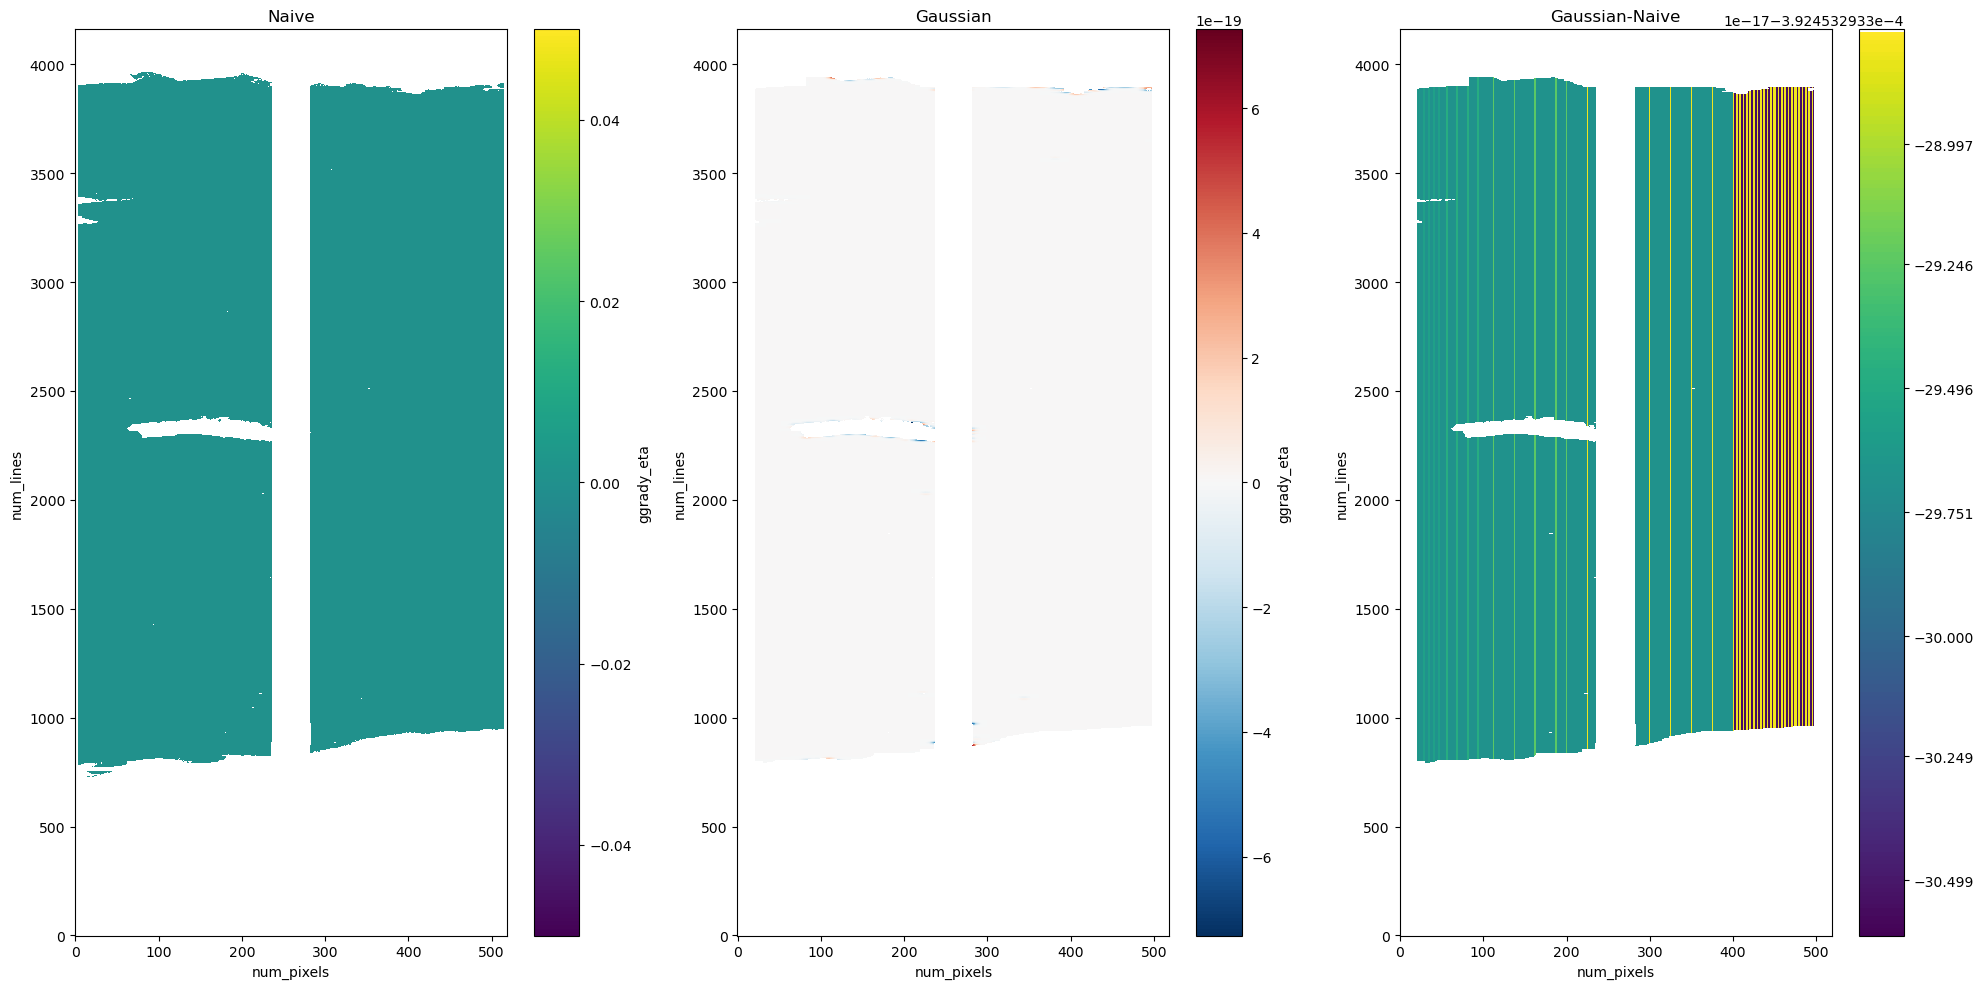

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
dss_naive.ggrady_eta.plot(ax=axes[0])
axes[0].set_title("Naive")
dss_gauss.ggrady_eta.plot(ax=axes[1])
axes[1].set_title("Gaussian")
(dss_gauss.ggrady_eta - dss_naive.ggradx_eta).plot(ax=axes[2])
axes[2].set_title("Gaussian-Naive")
fig.tight_layout()

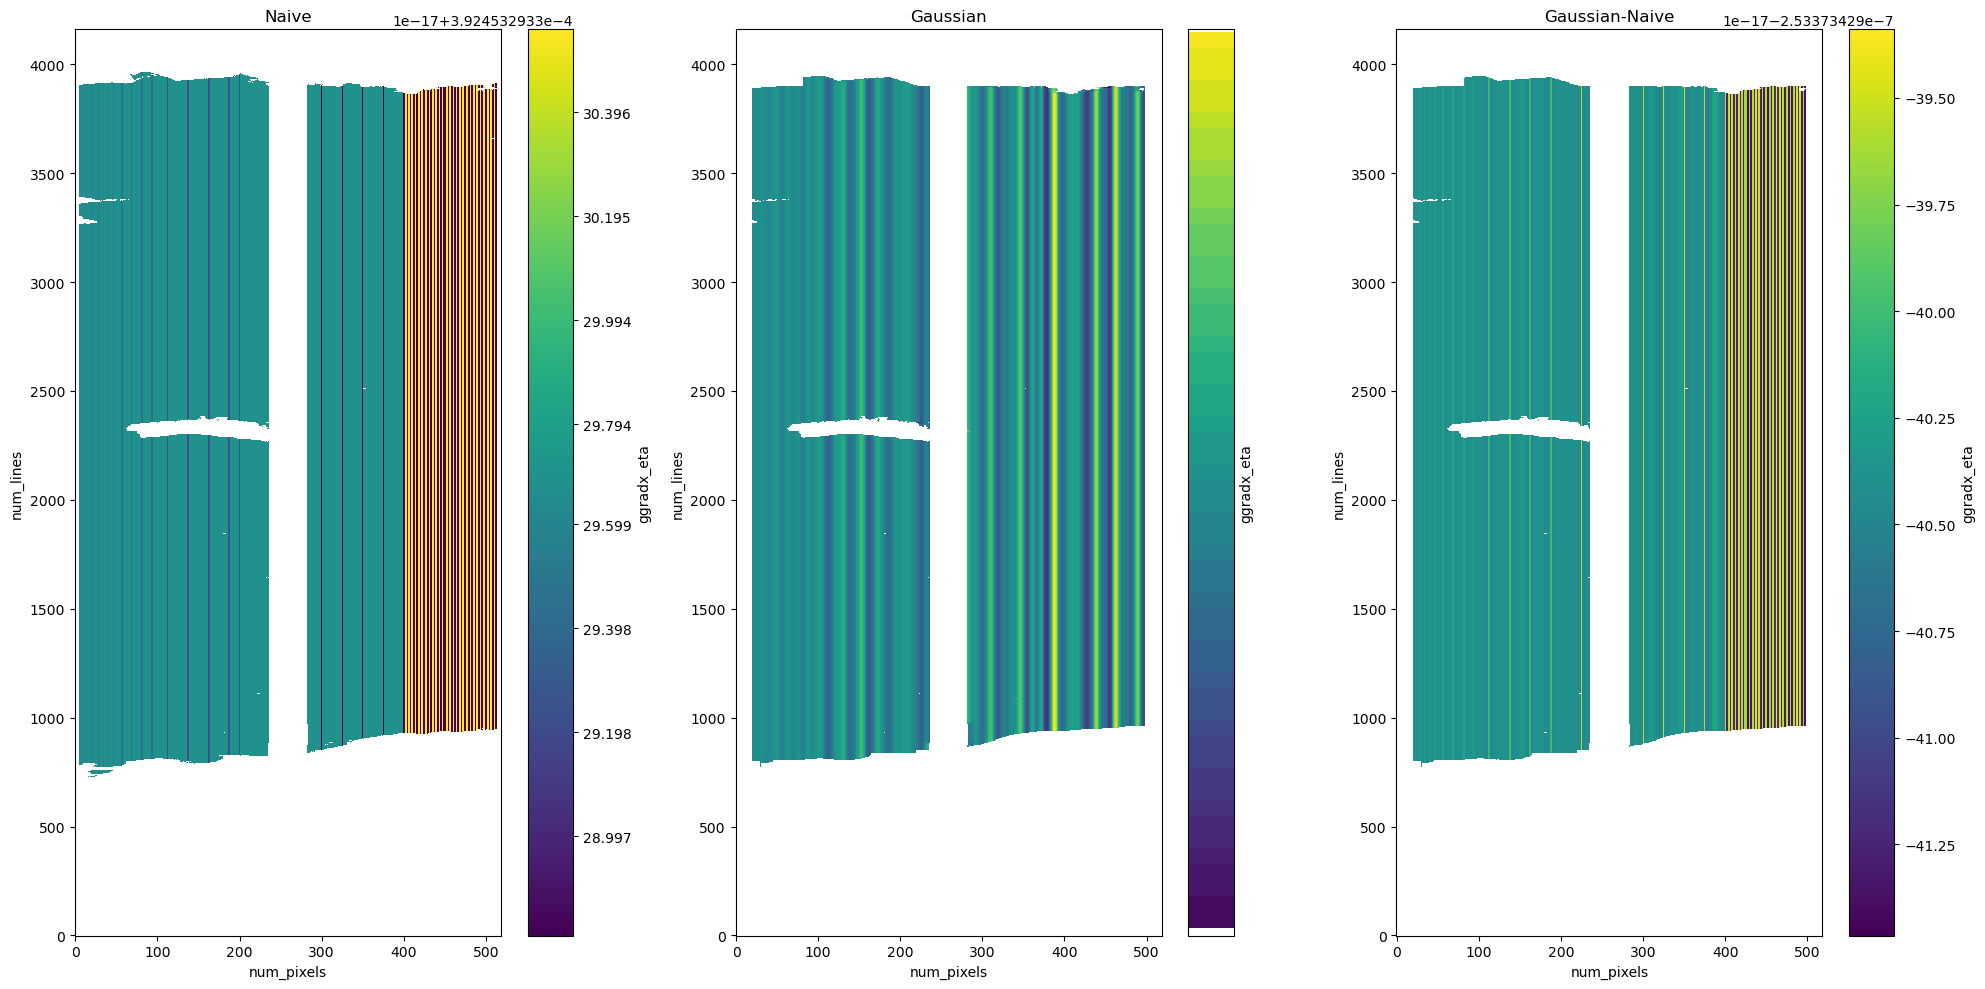

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
dss_naive.ggradx_eta.plot(ax=axes[0])
axes[0].set_title("Naive")
dss_gauss.ggradx_eta.plot(ax=axes[1])
axes[1].set_title("Gaussian")
(dss_gauss.ggradx_eta - dss_naive.ggradx_eta).plot(ax=axes[2])
axes[2].set_title("Gaussian-Naive")
fig.tight_layout()

In [14]:
dss_gauss.ggradx_eta.max(), dss_gauss.ggradx_eta.min()

(<xarray.DataArray 'ggradx_eta' ()> Size: 8B
 array(0.0003922),
 <xarray.DataArray 'ggradx_eta' ()> Size: 8B
 array(0.0003922))

In [15]:
dss_naive.ggradx_eta.max(), dss_naive.ggradx_eta.min()

(<xarray.DataArray 'ggradx_eta' ()> Size: 8B
 array(0.00039245),
 <xarray.DataArray 'ggradx_eta' ()> Size: 8B
 array(0.00039245))

# Interpolate 

In [16]:
dfr = pd.read_csv(
    os.path.join(zarr_dir, "drifters_" + drifters_sources.replace(".nc", ".csv"))
).set_index(
    "row_number"
)  # .drop(columns = 'Unnamed: 0').set_index('row_number')

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_15618/2234741544.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv'))).set_index('row_number')#.drop(columns = 'Unnamed: 0').set_index('row_number')


In [17]:
dfr_ = dfr.where((dfr.pass_number == swath) & (dfr.cycle_number == cycle)).dropna()

In [18]:
import pyinterp

mesh = pyinterp.RTree()


def interp_one_dataarray(da, new_lon, new_lat):
    lons = da.longitude.compute().data.flatten()
    lats = da.latitude.compute().data.flatten()
    data = da.compute().data.flatten()

    mesh.packing(np.vstack((lons, lats)).T, data)
    mx = new_lon
    my = new_lat

    idw, neighbors = mesh.inverse_distance_weighting(
        np.vstack((mx.ravel(), my.ravel())).T,
        within=False,  # Extrapolation is forbidden
        k=5,  # We are looking for at most 11 neighbors
        num_threads=0,
    )
    idw = idw.reshape(mx.shape)
    return idw


def interp_dss(dss, new_lon, new_lat):
    df_interp = pd.DataFrame()
    df_interp["longitude"] = new_lon
    df_interp["latitude"] = new_lat
    for v in dss:
        da = dss[v]
        df_interp[v] = interp_one_dataarray(da, new_lon, new_lat)
    return df_interp

In [19]:
da_interp = interp_one_dataarray(
    dss_gauss.ggradx_eta, dfr_.longitude.values, dfr_.latitude.values
)
len(da_interp)

3497

In [20]:
df_interp = interp_dss(dss_gauss, dfr_.longitude.values, dfr_.latitude.values)

In [21]:
df_interp

,longitude,latitude,ggradx_eta,ggradx_duacs_ssha_karin_2_filtered,ggrady_eta,ggrady_duacs_ssha_karin_2_filtered
0,5.045803,40.286533,0.000392,0.000002,0.0,-0.000016
1,5.046585,40.286116,0.000392,0.000002,0.0,-0.000016
2,5.047365,40.285685,0.000392,0.000002,0.0,-0.000015
3,5.048142,40.285242,0.000392,0.000001,0.0,-0.000015
4,5.048914,40.284784,0.000392,0.000001,0.0,-0.000015
...,...,...,...,...,...,...
3492,4.403015,40.324339,0.000392,-0.000005,0.0,-0.000026
3493,4.403785,40.323726,0.000392,-0.000004,0.0,-0.000026
3494,4.404564,40.323132,0.000392,-0.000004,0.0,-0.000025
3495,4.405359,40.322559,0.000392,-0.000004,0.0,-0.000025


(40.092591265205336, 43.44139292062064)

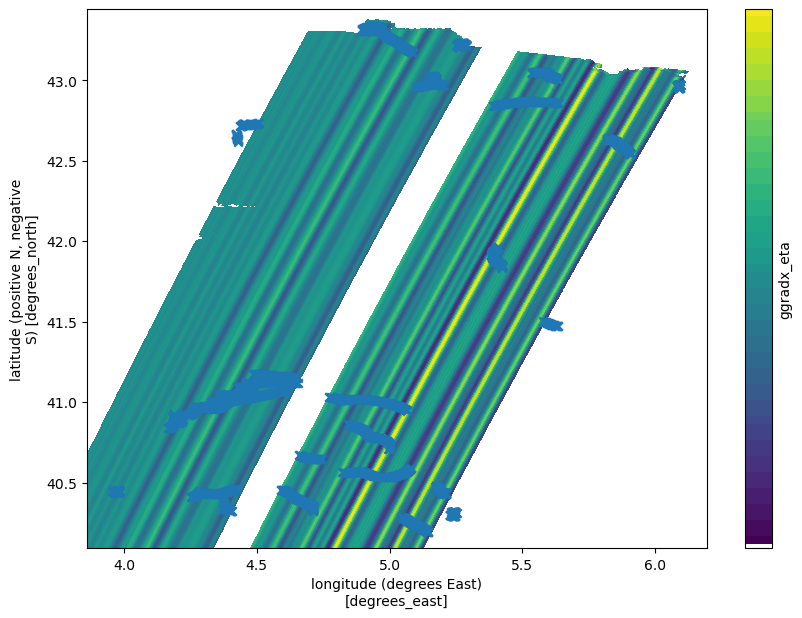

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

dss_gauss.ggradx_eta.plot(
    x="longitude", y="latitude", ax=ax
)  # , vmin = -5e-5, vmax = 5e-5)
ax.scatter(dfr_.longitude.values, dfr_.latitude.values, marker="x")  # , c=da_interp[1])
ax.set_xlim(dfr_.longitude.min() - 0.1, dfr_.longitude.max() + 0.1)
ax.set_ylim(dfr_.latitude.min() - 0.1, dfr_.latitude.max() + 0.1)

____________
# Compute and interp at once

In [33]:
def coloc_swot_cycle_swath(dfr, dfs, cycle, swath, method_gradient="gauss", cutoff=1e3):
    # select drifter point
    dfr_ = dfr.where((dfr.pass_number == swath) & (dfr.cycle_number == cycle)).dropna()
    dss = xr.open_dataset(
        dfs.where((dfs.pass_number == swath) & (dfs.cycle_number == cycle))
        .dropna()
        .file.values[0]
    )
    dss = add_grid_metrics(dss).reset_coords(["phi"])

    eta = np.zeros_like(dss.duacs_ssha_karin_2_filtered)
    for i in range(np.shape(eta)[0]):
        eta[i] = np.arange(0, len(eta[0])) / 100
    dss["eta"] = xr.DataArray(eta, dims=["num_lines", "num_pixels"]).where(
        ~dss["duacs_ssha_karin_2_filtered"].isnull()
    )

    if method_gradient == "naive":
        dss_ggrad = gradient_naive(dss, ggrad_variables)
    if method_gradient == "gauss":
        dss_ggrad = gradient_gauss(dss, ggrad_variables, cutoff=cutoff)
    dss = xr.merge([dss[variables], dss_ggrad])
    df_interp = interp_dss(dss, dfr_.longitude.values, dfr_.latitude.values)
    df_out = (
        pd.concat(
            [
                dfr_.reset_index()[["row_number", "longitude"]].set_index("longitude"),
                df_interp.set_index("longitude"),
            ],
            axis=1,
        )
        .reset_index()
        .set_index("row_number")
    )
    rotate_ggrad(df_out)
    return df_out


def coloc_swot(dfr, dfs, method_gradient="gauss", cutoff=1e3):
    DF = []
    for swath in dfr.pass_number.unique():
        for cycle in dfr.where(dfr.pass_number == swath).dropna().cycle_number.unique():
            DF.append(
                coloc_swot_cycle_swath(
                    dfr, dfs, cycle, swath, method_gradient, cutoff=1e3
                )
            )
    return pd.concat(DF)

# Rotate

In [34]:
def rotate(x, y, phi):
    return np.sin(phi) * x - np.cos(phi) * y, np.cos(phi) * x + np.sin(phi) * y


def rotate_ggrad(df):
    for v in ggrad_variables:
        df["ggrade_" + v], df["ggradn_" + v] = rotate(
            df["ggradx_" + v], df["ggrady_" + v], df["phi"]
        )

## Test rotation

In [35]:
cycle = 500
swath = 3
dfg = coloc_swot_cycle_swath(
    dfr, dfs, cycle, swath, method_gradient="gauss", cutoff=1e3
)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [36]:
dfg

,longitude,latitude,ancillary_surface_classification_flag,cross_track_distance,cvl_distance_to_coast,cvl_swh_model,duacs_editing_flag,duacs_phase_screen,duacs_phase_screen_orbit,duacs_phase_screen_static,...,ssh_karin_2_qual,phi,ggradx_eta,ggradx_duacs_ssha_karin_2_filtered,ggrady_eta,ggrady_duacs_ssha_karin_2_filtered,ggrade_eta,ggradn_eta,ggrade_duacs_ssha_karin_2_filtered,ggradn_duacs_ssha_karin_2_filtered
row_number,,,,,,,,,,,,,,,,,,,,,
55549,5.045803,40.286533,0.0,47964.445386,73748.316448,0.485000,0.0,0.001328,-0.000014,-0.000157,...,0.0,1.809080,0.000392,0.000002,0.0,-0.000016,0.000381,-0.000093,-0.000002,-0.000016
55550,5.046585,40.286116,0.0,48022.723072,73745.809603,0.485000,0.0,0.001297,0.000009,-0.000064,...,0.0,1.809047,0.000392,0.000002,0.0,-0.000016,0.000381,-0.000093,-0.000002,-0.000016
55551,5.047365,40.285685,0.0,48096.306495,73726.202558,0.485000,0.0,0.001261,0.000039,0.000054,...,0.0,1.809063,0.000392,0.000002,0.0,-0.000015,0.000381,-0.000093,-0.000002,-0.000015
55552,5.048142,40.285242,0.0,48197.370855,73848.036692,0.485000,0.0,0.001221,0.000079,0.000216,...,0.0,1.809173,0.000392,0.000001,0.0,-0.000015,0.000381,-0.000093,-0.000002,-0.000015
55553,5.048914,40.284784,0.0,48250.578606,73962.580815,0.485000,0.0,0.001200,0.000100,0.000301,...,0.0,1.809319,0.000392,0.000001,0.0,-0.000015,0.000381,-0.000093,-0.000002,-0.000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59041,4.403015,40.324339,0.0,-6165.073571,35000.000000,0.463000,0.0,0.014036,0.000000,-0.000868,...,0.0,1.801599,0.000392,-0.000005,0.0,-0.000026,0.000382,-0.000090,-0.000010,-0.000024
59042,4.403785,40.323726,0.0,-6053.994209,35000.000000,0.463056,0.0,0.014214,0.000000,-0.000845,...,0.0,1.801365,0.000392,-0.000004,0.0,-0.000026,0.000382,-0.000090,-0.000010,-0.000024
59043,4.404564,40.323132,0.0,-5983.711911,35000.000000,0.463124,0.0,0.014326,0.000000,-0.000764,...,0.0,1.801130,0.000392,-0.000004,0.0,-0.000025,0.000382,-0.000090,-0.000010,-0.000024
